In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC as SupportVectorMachineClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
from imblearn.under_sampling import NearMiss
from scipy.stats import wilcoxon

In [2]:
df = pd.read_csv('heart_failure.csv')

In [3]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [4]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

In [5]:
numerical_features = ["age", "creatinine_phosphokinase", "ejection_fraction", "platelets", "serum_creatinine", "serum_sodium"]
print("Numerical features:")
print(numerical_features)

Numerical features:
['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium']


In [6]:
categorical_features = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]
print("Categorical features:")
print(categorical_features)

Categorical features:
['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']


In [7]:
df.info(categorical_features)

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [8]:
df.info(numerical_features)

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [9]:
all_features = categorical_features.copy()
all_features.extend(numerical_features)

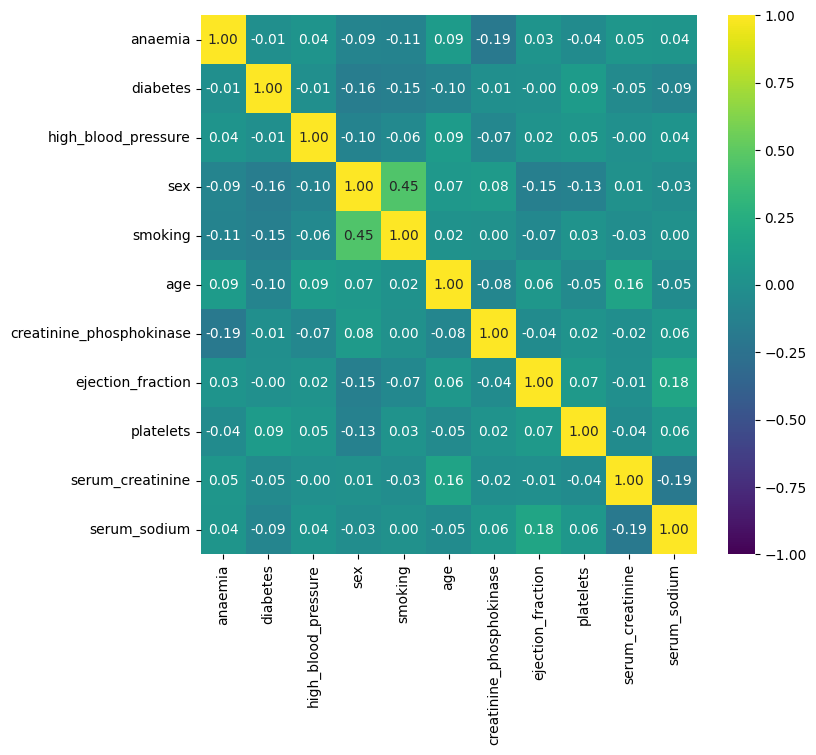

In [10]:
# Correlation Matrix
plt.figure(figsize=(8, 7))
sns.heatmap(df[all_features].corr(method='pearson'), vmin=-1, vmax=1, cmap='viridis', annot=True, fmt='.2f');

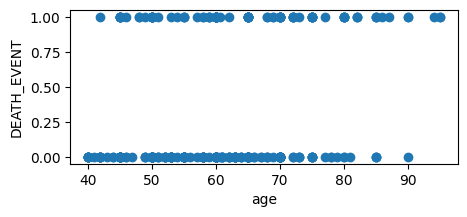

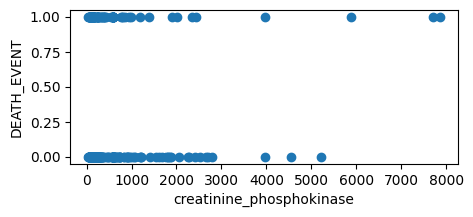

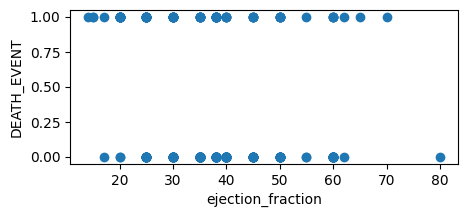

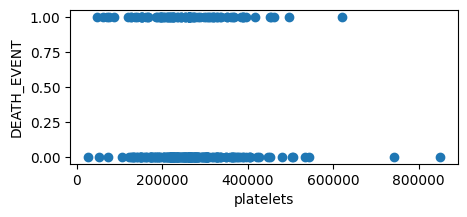

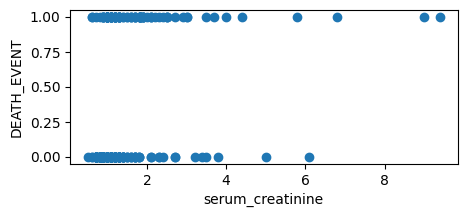

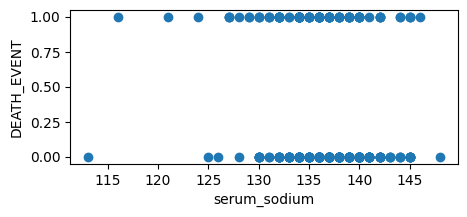

In [11]:
# Scatter Plot
for feature in numerical_features:
  plt.figure(figsize=(5, 2))
  plt.scatter(df[feature], df['DEATH_EVENT'])
  plt.xlabel(feature)
  plt.ylabel('DEATH_EVENT')
  plt.show()


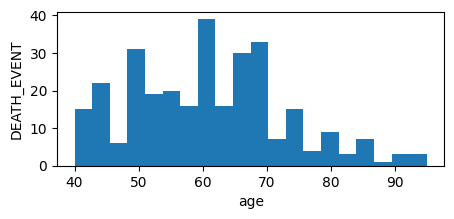

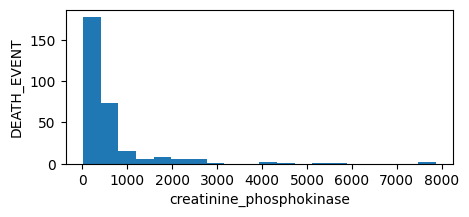

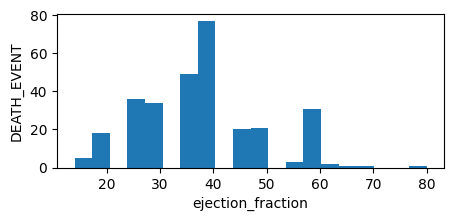

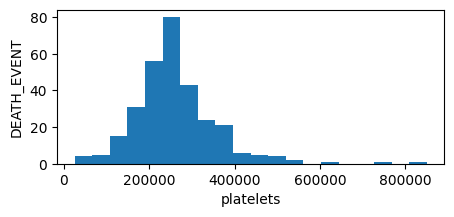

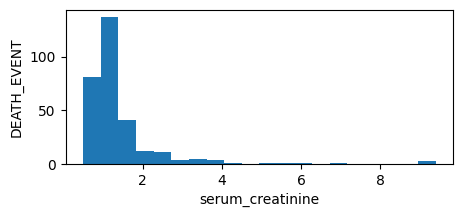

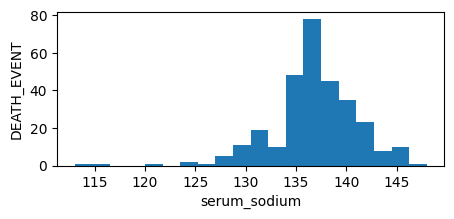

In [12]:
# Histogram
for feature in numerical_features:
  plt.figure(figsize=(5, 2))
  plt.hist(df[feature], bins=20)
  plt.xlabel(feature)
  plt.ylabel('DEATH_EVENT')
  plt.show()

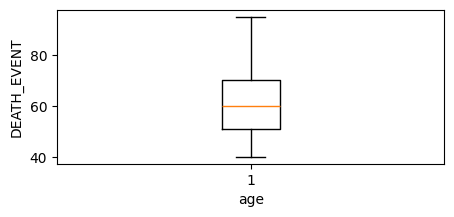

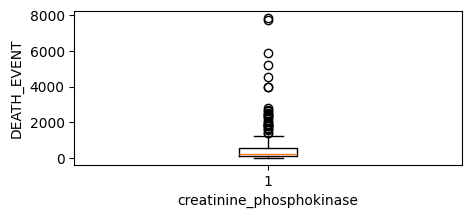

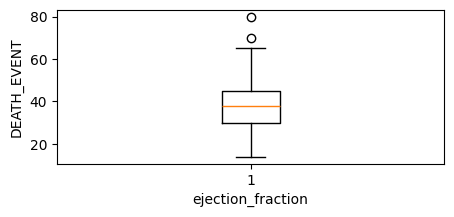

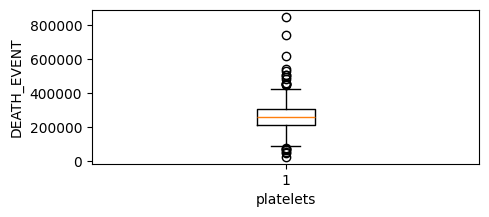

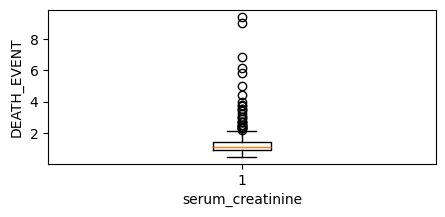

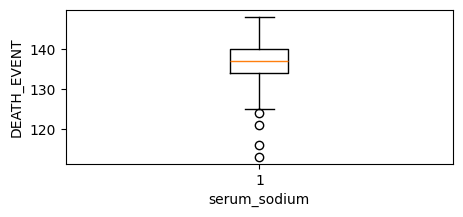

In [13]:
for feature in numerical_features:
  plt.figure(figsize=(5, 2))
  plt.boxplot(df[feature])
  plt.xlabel(feature)
  plt.ylabel('DEATH_EVENT')
  plt.show()

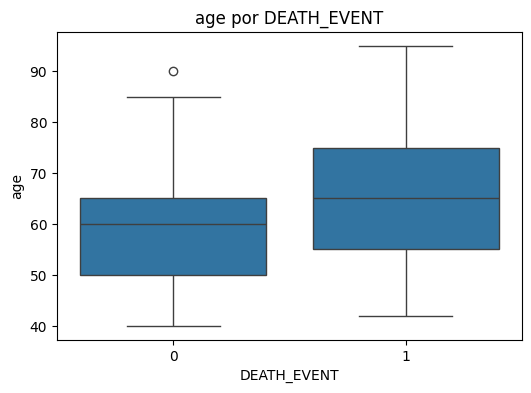

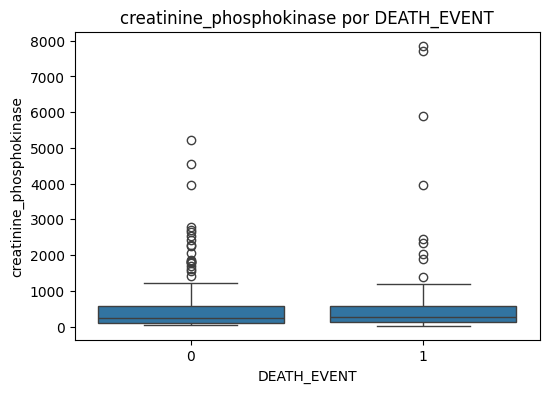

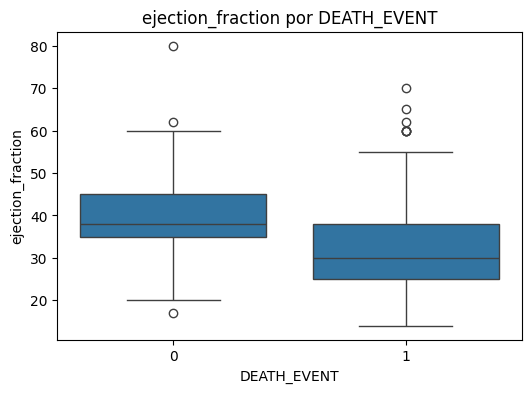

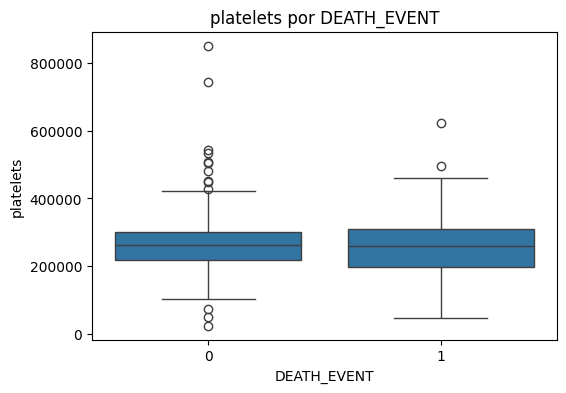

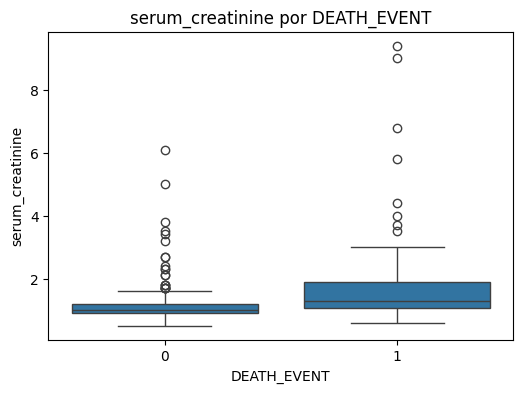

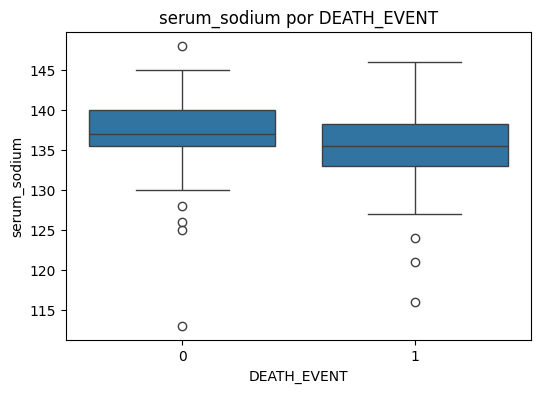

In [14]:
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='DEATH_EVENT', y=feature, data=df)
    plt.title(f'{feature} por DEATH_EVENT')
    plt.show()

In [15]:
df = df.drop(columns=['time', 'sex'])

In [16]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,1
...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,0


In [17]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# nm = NearMiss()
# X_undersampled, y_undersampled = nm.fit_resample(X, y)

In [18]:
df_cleaned = pd.Series(y).value_counts()
print("Class distribution after NearMiss:")
print(df_cleaned)

Class distribution after NearMiss:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution After NearMiss'}, xlabel='DEATH_EVENT'>

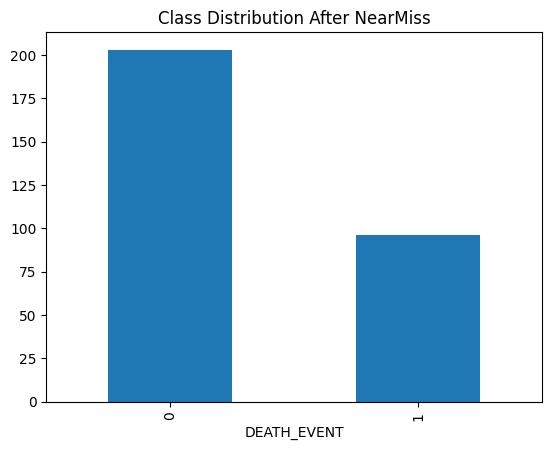

In [19]:
df_cleaned.plot(kind='bar', title='Class Distribution After NearMiss')


In [20]:
X = X.values
y = y.values

In [21]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
X

array([[7.500e+01, 0.000e+00, 5.820e+02, ..., 1.900e+00, 1.300e+02,
        0.000e+00],
       [5.500e+01, 0.000e+00, 7.861e+03, ..., 1.100e+00, 1.360e+02,
        0.000e+00],
       [6.500e+01, 0.000e+00, 1.460e+02, ..., 1.300e+00, 1.290e+02,
        1.000e+00],
       ...,
       [4.500e+01, 0.000e+00, 2.060e+03, ..., 8.000e-01, 1.380e+02,
        0.000e+00],
       [4.500e+01, 0.000e+00, 2.413e+03, ..., 1.400e+00, 1.400e+02,
        1.000e+00],
       [5.000e+01, 0.000e+00, 1.960e+02, ..., 1.600e+00, 1.360e+02,
        1.000e+00]], shape=(299, 10))

In [23]:
# print("Shape of X_undersampled:", X_undersampled.shape)
# print("Shape of y_undersampled:", y_undersampled.shape)

In [24]:
df_cleaned.value_counts('DEATH_EVENT')

count
203    0.5
96     0.5
Name: proportion, dtype: float64

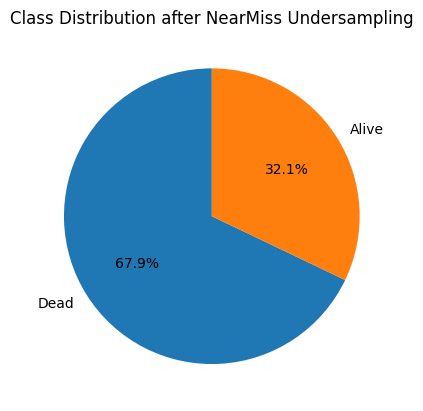

In [25]:
# SETORIAL GRAPHIC FOR CLASS
labels = ['Dead', 'Alive']
sizes = [df_cleaned[0], df_cleaned[1]] # Accessing counts by index directly
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution after NearMiss Undersampling')
plt.show()

In [26]:
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X)
# Crio um DataFrame temporário só pra ser mais fácil de pintar
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
# Adiciono uma coluna com a resposta certa (Y) para ele colorir os pontinhos
# Assumindo que a sua resposta é o 'y'
df_pca['Classe_Alvo'] = y


<Axes: xlabel='PC1', ylabel='PC2'>

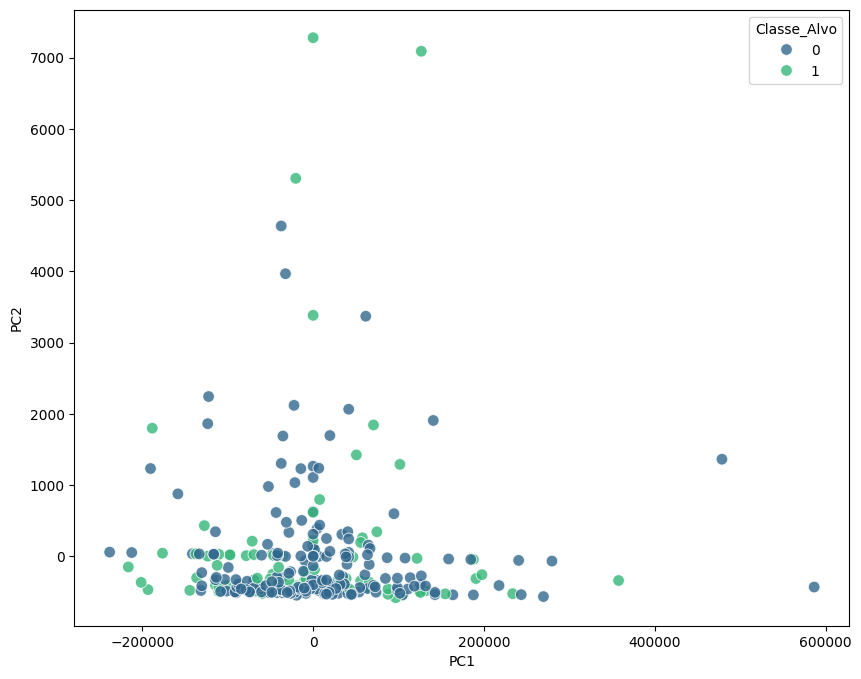

In [27]:

plt.figure(figsize=(10, 8))
# O seaborn desenha o Scatter Plot com Cores automáticas!
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Classe_Alvo', 
    palette='viridis', # Tente 'Set1' ou 'coolwarm' também
    data=df_pca, 
    alpha=0.8,
    s=70 # Tamanho da bolinha
)



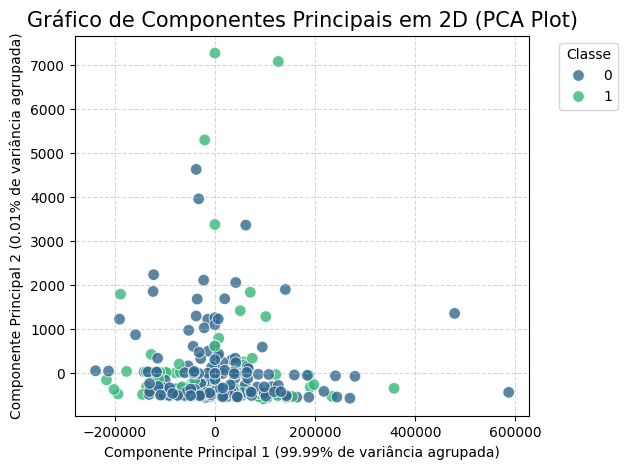

In [28]:
sns.scatterplot(x='PC1', y='PC2', hue='Classe_Alvo', palette='viridis', data=df_pca, alpha=0.8, s=70)
expl_1 = pca.explained_variance_ratio_[0]*100
expl_2 = pca.explained_variance_ratio_[1]*100
plt.title('Gráfico de Componentes Principais em 2D (PCA Plot)', fontsize=15)
plt.xlabel(f"Componente Principal 1 ({expl_1:.2f}% de variância agrupada)")
plt.ylabel(f"Componente Principal 2 ({expl_2:.2f}% de variância agrupada)")
plt.legend(title='Classe', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

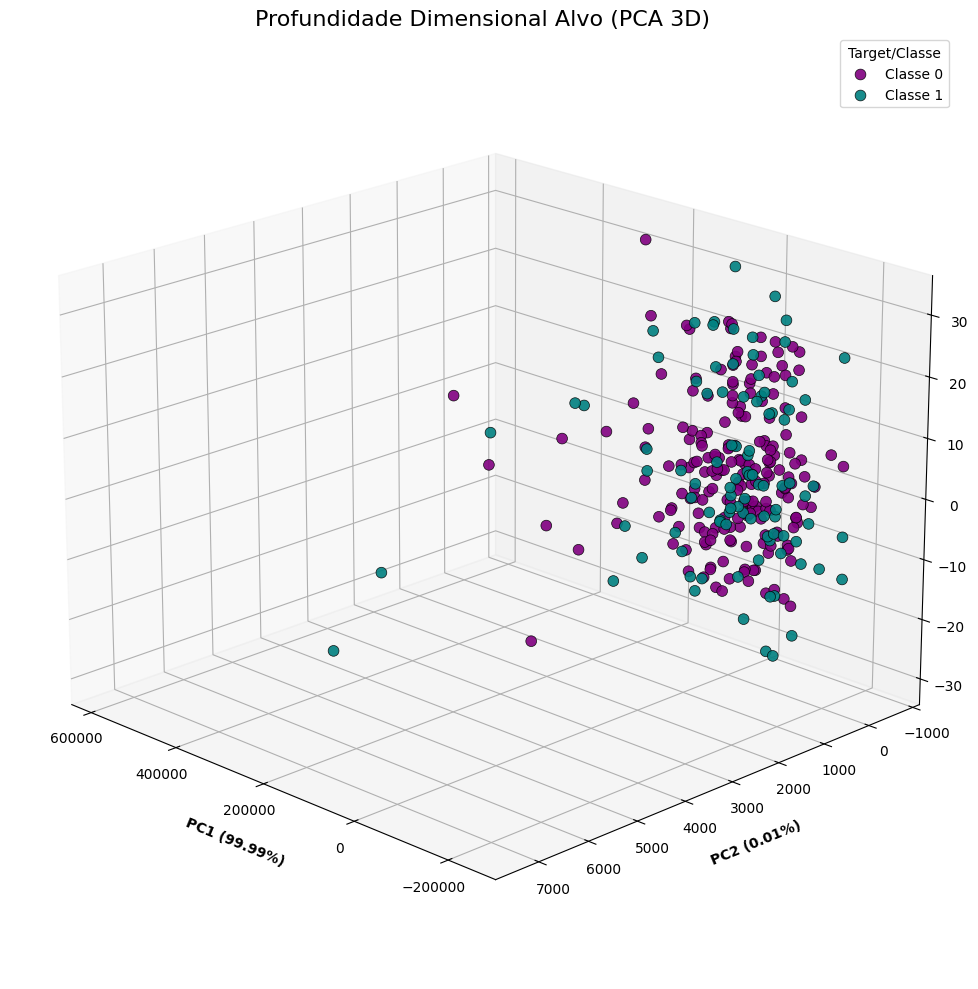

In [29]:
pca_3d = PCA(n_components=3)
comps_3d = pca_3d.fit_transform(X)
    
df_pca3 = pd.DataFrame(data=comps_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca3['Classe_Alvo'] = y
    
# Matplotlib puro pro 3D 
fig3d = plt.figure(figsize=(12, 10))
ax = fig3d.add_subplot(111, projection='3d')

cores = ['purple', 'teal', 'gold'] 
classes_unicas = sorted(list(df_pca3['Classe_Alvo'].unique()))
    
# Plota classe por classe
for cls, cor in zip(classes_unicas, cores):
    subset = df_pca3[df_pca3['Classe_Alvo'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
                color=cor, label=f'Classe {cls}', s=60, alpha=0.9, edgecolor='black', linewidth=0.5)

e1_3d = pca_3d.explained_variance_ratio_[0]*100
e2_3d = pca_3d.explained_variance_ratio_[1]*100
e3_3d = pca_3d.explained_variance_ratio_[2]*100

ax.set_xlabel(f"PC1 ({e1_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_ylabel(f"PC2 ({e2_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_zlabel(f"PC3 ({e3_3d:.2f}%)", fontweight='bold', labelpad=10)
plt.title('Profundidade Dimensional Alvo (PCA 3D)', fontsize=16)
plt.legend(title='Target/Classe', loc='best')

# Opcional (rotacionar ângulo)
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.show()

In [30]:
df = df_cleaned

In [31]:
kfold =  KFold(n_splits=10, shuffle=True, random_state=42)

In [32]:
param_grid_KNN = {
    'n_neighbors': [5, 7, 9, 15, 20, 25],
    'metrics': ['euclidean', 'manhattan', 'cosine', 'minkowski', 'hamming']
    }

In [33]:
param_grid_DT = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10],
}


In [34]:
param_grid_RF = {
    'n_estimators': [50, 100, 200, 300], 
    'max_depth': [10, 40, 50, 70, 100], 
    'min_samples_split': [2, 5, 8]
    }

In [35]:
param_grid_SVM = {
    'C': [0.1, 1, 10, 100], 
    'kernel': ['linear', 'rbf', 'poly']
    }

In [36]:
param_grid_MLP = {
    'hidden_layer_sizes': [(32, 16), (64,)], 
     'alpha': [0.01, 0.1, 1.0], # Parâmetro decisivo para ignorar 'névoas' nos dados
     'learning_rate_init': [0.001], 
     'activation': ['relu', 'tanh'], 
     'solver': ['adam'], 
     'max_iter': [2000],
     'early_stopping': [True], 
     'random_state': [42],
}

In [37]:

param_grid_LR = {
    'C': [0.01, 0.1, 1, 10],
     'solver': ['saga'],
     'penalty': ['l1', 'l2'],
}


In [38]:
param_grid_XGB = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1, 1.0],
}

In [39]:
param_grid_NB = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [40]:
param_grid_NC = {
    'metric': ['euclidean', 'manhattan'],
    'shrink_threshold': [None, 0.1, 0.5, 1.0]
}

In [41]:

S = MinMaxScaler()

In [42]:
test_scores_KNN = []
acc_test_scores_KNN = []
precision_test_scores_KNN = []
recall_test_scores_KNN = []
f1_test_scores_KNN = []
auroc_test_scores_KNN = []

test_scores_DT = []
acc_test_scores_DT = []
precision_test_scores_DT = []
recall_test_scores_DT = []
f1_test_scores_DT = []
auroc_test_scores_DT = []

test_scores_RF = []
acc_test_scores_RF = []
precision_test_scores_RF = []
recall_test_scores_RF = []
f1_test_scores_RF = []
auroc_test_scores_RF = []

test_scores_SVM = []
acc_test_scores_SVM = []
precision_test_scores_SVM = []
recall_test_scores_SVM = []
f1_test_scores_SVM = []
auroc_test_scores_SVM = []

test_scores_MLP = []
acc_test_scores_MLP = []
precision_test_scores_MLP = []
recall_test_scores_MLP = []
f1_test_scores_MLP = []
auroc_test_scores_MLP = []

test_scores_LR = []
acc_test_scores_LR = []
precision_test_scores_LR = []
recall_test_scores_LR = []
f1_test_scores_LR = []
auroc_test_scores_LR = []

test_scores_XGB = []
acc_test_scores_XGB = []
precision_test_scores_XGB = []
recall_test_scores_XGB = []
f1_test_scores_XGB = []
auroc_test_scores_XGB = []

test_scores_NB = []
acc_test_scores_NB = []
precision_test_scores_NB = []
recall_test_scores_NB = []
f1_test_scores_NB = []
auroc_test_scores_NB = []

test_scores_NC = []
acc_test_scores_NC = []
precision_test_scores_NC = []
recall_test_scores_NC = []
f1_test_scores_NC = []
auroc_test_scores_NC = []

In [43]:
confusion_matrices_KNN = []
confusion_matrices_DT = []
confusion_matrices_RF = []
confusion_matrices_SVM = []
confusion_matrices_MLP = []
confusion_matrices_LR = []
confusion_matrices_XGB = []
confusion_matrices_NB = []
confusion_matrices_NC = []

In [44]:
def validation_metric(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

In [45]:
for i, (train_index, test_index) in enumerate(kfold.split(X)):
    x_train, x_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    x_train_D, x_val, y_train_D, y_val = train_test_split(x_train, y_train, test_size=0.2)

    params_KNN = []
    f1_val_KNN = []

    params_DT = []
    f1_val_DT = []

    params_RF = []
    f1_val_RF = []

    params_SVM = []
    f1_val_SVM = []

    params_MLP = []
    f1_val_MLP = []

    params_LR = []
    f1_val_LR = []

    params_XGB = []
    f1_val_XGB = []

    params_NB = []
    f1_val_NB = []

    params_NC = []
    f1_val_NC = []

    x_train_S = S.fit_transform(x_train)
    x_test_S = S.transform(x_test)


    x_train_D_S = S.fit_transform(x_train_D)
    x_val_S = S.transform(x_val)


    for params in ParameterGrid(param_grid_KNN):
        knn = KNeighborsClassifier(n_neighbors=params['n_neighbors'], metric=params['metrics'])
        knn.fit(x_train_D_S, y_train_D)
        y_pred = knn.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_KNN.append(params)
        f1_val_KNN.append(validation_metric(y_val, y_pred))

    for params in ParameterGrid(param_grid_DT):
        dt = DecisionTreeClassifier(max_depth=params['max_depth'], random_state=42)
        dt.fit(x_train_D_S, y_train_D)
        y_pred = dt.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_DT.append(params)
        f1_val_DT.append(validation_metric(y_val, y_pred))

    for params in ParameterGrid(param_grid_RF):
        rf = RandomForestClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42)
        rf.fit(x_train_D_S, y_train_D)
        y_pred = rf.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_RF.append(params)
        f1_val_RF.append(validation_metric(y_val, y_pred))

    for params in ParameterGrid(param_grid_SVM):
        svm = SupportVectorMachineClassifier(C=params['C'], kernel=params['kernel'], probability=True, random_state=42)
        svm.fit(x_train_D_S, y_train_D)
        y_pred = svm.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_SVM.append(params)
        f1_val_SVM.append(validation_metric(y_val, y_pred))

    for params in ParameterGrid(param_grid_MLP):

      mlp = MLPClassifier(
          hidden_layer_sizes=params['hidden_layer_sizes'],
          alpha=params['alpha'],
          learning_rate_init=params['learning_rate_init'],
          activation=params['activation'],
          solver=params['solver'],
          max_iter=params['max_iter'],
          early_stopping=params['early_stopping'],
          random_state=params['random_state']
      )

      mlp.fit(x_train_D_S, y_train_D)
      y_pred = mlp.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_MLP.append(params)
      f1_val_MLP.append(validation_metric(y_val, y_pred))

    for params in ParameterGrid(param_grid_LR):
      lr = LogisticRegression(C=params['C'], solver='saga', max_iter=1000, random_state=42)
      lr.fit(x_train_D_S, y_train_D)
      y_pred = lr.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_LR.append(params)
      f1_val_LR.append(validation_metric(y_val, y_pred))

    for params in ParameterGrid(param_grid_XGB):
      xgb = XGBClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42)
      xgb.fit(x_train_D_S, y_train_D)
      y_pred = xgb.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_XGB.append(params)
      f1_val_XGB.append(validation_metric(y_val, y_pred))

    for params in ParameterGrid(param_grid_NB):
      nb = GaussianNB(var_smoothing=params['var_smoothing'])
      nb.fit(x_train_D_S, y_train_D)
      y_pred = nb.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_NB.append(params)
      f1_val_NB.append(validation_metric(y_val, y_pred))

    for params in ParameterGrid(param_grid_NC):
      nc = NearestCentroid(metric=params['metric'], shrink_threshold=params['shrink_threshold'])
      nc.fit(x_train_D_S, y_train_D)
      y_pred = nc.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_NC.append(params)
      f1_val_NC.append(validation_metric(y_val, y_pred))

    print(f"Fold {i+1}:")

    best_params_KNN = params_KNN[f1_val_KNN.index(max(f1_val_KNN))]
    best_params_DT  = params_DT[f1_val_DT.index(max(f1_val_DT))]
    best_params_RF  = params_RF[f1_val_RF.index(max(f1_val_RF))]
    best_params_SVM = params_SVM[f1_val_SVM.index(max(f1_val_SVM))]
    best_params_MLP = params_MLP[f1_val_MLP.index(max(f1_val_MLP))]
    best_params_LR  = params_LR[f1_val_LR.index(max(f1_val_LR))]
    best_params_XGB = params_XGB[f1_val_XGB.index(max(f1_val_XGB))]
    best_params_NB = params_NB[f1_val_NB.index(max(f1_val_NB))]
    best_params_NC = params_NC[f1_val_NC.index(max(f1_val_NC))]
    

    knn = KNeighborsClassifier(n_neighbors=best_params_KNN['n_neighbors'], metric=best_params_KNN['metrics'])
    knn.fit(x_train_S, y_train)
    y_pred_knn = knn.predict(x_test_S)
    knn_acc = accuracy_score(y_test, y_pred_knn)
    knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
    knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
    knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')
    knn_auroc = roc_auc_score(y_test, y_pred_knn, average='weighted')

    cm_knn = confusion_matrix(y_test, y_pred_knn)
    confusion_matrices_KNN.append(cm_knn)

    acc_test_scores_KNN.append(knn_acc)
    precision_test_scores_KNN.append(knn_precision)
    recall_test_scores_KNN.append(knn_recall)
    f1_test_scores_KNN.append(knn_f1)
    auroc_test_scores_KNN.append(knn_auroc)

    print(f"\tKNeighborsClassifier:")
    print(f"\t- Melhor n_neighbors: {best_params_KNN['n_neighbors']}")
    print(f"\t- acuracia do teste: {knn_acc:.2f}")
    print(f"\t- Precision no teste: {knn_precision:.4f}")
    print(f"\t- Recall no teste: {knn_recall:.4f}")
    print(f"\t- F1 no teste: {knn_f1:.4f}")
    print(f"\t- AUROC no teste: {knn_auroc:.4f}")

    dt = DecisionTreeClassifier(max_depth=best_params_DT['max_depth'], random_state=42)
    dt.fit(x_train_S, y_train)
    y_pred_dt = dt.predict(x_test_S)
    dt_acc = accuracy_score(y_test, y_pred_dt)
    dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
    dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
    dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')
    dt_auroc = roc_auc_score(y_test, y_pred_dt, average='weighted')

    cm_dt = confusion_matrix(y_test, y_pred_dt)
    confusion_matrices_DT.append(cm_dt)

    acc_test_scores_DT.append(dt_acc)
    precision_test_scores_DT.append(dt_precision)
    recall_test_scores_DT.append(dt_recall)
    f1_test_scores_DT.append(dt_f1)
    auroc_test_scores_DT.append(dt_auroc)


    print(f"\n\tDecisionTreeClassifier:")
    print(f"\t- Melhor max_depth: {best_params_DT['max_depth']}")
    print(f"\t- acuracia do teste: {dt_acc:.2f}")
    print(f"\t- Precision no teste: {dt_precision:.4f}")
    print(f"\t- Recall no teste: {dt_recall:.4f}")
    print(f"\t- F1 no teste: {dt_f1:.4f}")
    print(f"\t- AUROC no teste: {dt_auroc:.4f}")

    rf = RandomForestClassifier(n_estimators=best_params_RF['n_estimators'], max_depth=best_params_RF['max_depth'], random_state=42)
    rf.fit(x_train_S, y_train)
    y_pred_rf = rf.predict(x_test_S)
    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
    rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
    rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
    rf_auroc = roc_auc_score(y_test, y_pred_rf, average='weighted')

    cm_rf = confusion_matrix(y_test, y_pred_rf)
    confusion_matrices_RF.append(cm_rf)

    acc_test_scores_RF.append(rf_acc)
    precision_test_scores_RF.append(rf_precision)
    recall_test_scores_RF.append(rf_recall)
    f1_test_scores_RF.append(rf_f1)
    auroc_test_scores_RF.append(rf_auroc)

    print(f"\n\tRandomForestClassifier:")
    print(f"\t- Melhor n_estimators: {best_params_RF['n_estimators']}")
    print(f"\t- Melhor max_depth: {best_params_RF['max_depth']}")
    print(f"\t- acuracia do teste: {rf_acc:.2f}")
    print(f"\t- Precision no teste: {rf_precision:.4f}")
    print(f"\t- Recall no teste: {rf_recall:.4f}")
    print(f"\t- F1 no teste: {rf_f1:.4f}")
    print(f"\t- AUROC no teste: {rf_auroc:.4f}")

    svm.fit(x_train_S, y_train)
    y_pred_svm = svm.predict(x_test_S)
    svm_acc = accuracy_score(y_test, y_pred_svm)
    svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
    svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
    svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
    svm_auroc = roc_auc_score(y_test, y_pred_svm, average='weighted')

    cm_svm = confusion_matrix(y_test, y_pred_svm)
    confusion_matrices_SVM.append(cm_svm)

    acc_test_scores_SVM.append(svm_acc)
    precision_test_scores_SVM.append(svm_precision)
    recall_test_scores_SVM.append(svm_recall)
    f1_test_scores_SVM.append(svm_f1)
    auroc_test_scores_SVM.append(svm_auroc)

    print(f"\n\tSVM:")
    print(f"\t- Melhor C: {best_params_SVM['C']}")
    print(f"\t- Melhor kernel: {best_params_SVM['kernel']}")
    print(f"\t- acuracia do teste: {svm_acc:.2f}")
    print(f"\t- Precision no teste: {svm_precision:.4f}")
    print(f"\t- Recall no teste: {svm_recall:.4f}")
    print(f"\t- F1 no teste: {svm_f1:.4f}")
    print(f"\t- AUROC no teste: {svm_auroc:.4f}")

    mlp = MLPClassifier(**best_params_MLP)
    mlp.fit(x_train_S, y_train)
    y_pred_mlp = mlp.predict(x_test_S)
    mlp_acc = accuracy_score(y_test, y_pred_mlp)
    mlp_precision = precision_score(y_test, y_pred_mlp, average='weighted')
    mlp_recall = recall_score(y_test, y_pred_mlp, average='weighted')
    mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')
    mlp_auroc = roc_auc_score(y_test, y_pred_mlp, average='weighted')

    cm_mlp = confusion_matrix(y_test, y_pred_mlp)
    confusion_matrices_MLP.append(cm_mlp)

    acc_test_scores_MLP.append(mlp_acc)
    precision_test_scores_MLP.append(mlp_precision)
    recall_test_scores_MLP.append(mlp_recall)
    f1_test_scores_MLP.append(mlp_f1)
    auroc_test_scores_MLP.append(mlp_auroc)

    print(f"\n\tMLPClassifier:")
    print(f"\t- Melhor hidden_layer_sizes: {best_params_MLP['hidden_layer_sizes']}")
    print(f"\t- Melhor alpha: {best_params_MLP['alpha']}")
    print(f"\t- Melhor learning_rate_init: {best_params_MLP['learning_rate_init']}")
    print(f"\t- Acurácia no teste: {mlp_acc:.4f}")
    print(f"\t- Precision no teste: {mlp_precision:.4f}")
    print(f"\t- Recall no teste: {mlp_recall:.4f}")
    print(f"\t- F1 no teste: {mlp_f1:.4f}")
    print(f"\t- AUROC no teste: {mlp_auroc:.4f}")


    lr = LogisticRegression(**best_params_LR)
    lr.fit(x_train_S, y_train)
    y_pred_lr = lr.predict(x_test_S)
    lr_acc = accuracy_score(y_test, y_pred_lr)
    lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
    lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
    lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
    lr_auroc = roc_auc_score(y_test, y_pred_lr, average='weighted')

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    confusion_matrices_LR.append(cm_lr)

    acc_test_scores_LR.append(lr_acc)
    precision_test_scores_LR.append(lr_precision)
    recall_test_scores_LR.append(lr_recall)
    f1_test_scores_LR.append(lr_f1)
    auroc_test_scores_LR.append(lr_auroc)

    print(f"\n\tLogisticRegression:")
    print(f"\t- Melhor C: {best_params_LR['C']}")
    print(f"\t- Acurácia no teste: {lr_acc:.4f}")
    print(f"\t- Precision no teste: {lr_precision:.4f}")
    print(f"\t- Recall no teste: {lr_recall:.4f}")
    print(f"\t- F1 no teste: {lr_f1:.4f}")
    print(f"\t- AUROC no teste: {lr_auroc:.4f}")

    xgb = XGBClassifier(**best_params_XGB)
    xgb.fit(x_train_S, y_train)
    y_pred_xgb = xgb.predict(x_test_S)
    xgb_acc = accuracy_score(y_test, y_pred_xgb)
    xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted')
    xgb_recall = recall_score(y_test, y_pred_xgb, average='weighted')
    xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')
    xgb_auroc = roc_auc_score(y_test, y_pred_xgb, average='weighted')

    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    confusion_matrices_XGB.append(cm_xgb)

    acc_test_scores_XGB.append(xgb_acc)
    precision_test_scores_XGB.append(xgb_precision)
    recall_test_scores_XGB.append(xgb_recall)
    f1_test_scores_XGB.append(xgb_f1)
    auroc_test_scores_XGB.append(xgb_auroc)

    print(f"\n\tXGBClassifier:")
    print(f"\t- Melhor n_estimators: {best_params_XGB['n_estimators']}")
    print(f"\t- Melhor max_depth: {best_params_XGB['max_depth']}")
    print(f"\t- Acurácia no teste: {xgb_acc:.4f}")
    print(f"\t- Precision no teste: {xgb_precision:.4f}")
    print(f"\t- Recall no teste: {xgb_recall:.4f}")
    print(f"\t- F1 no teste: {xgb_f1:.4f}")
    print(f"\t- AUROC no teste: {xgb_auroc:.4f}")

    nb = GaussianNB(**best_params_NB)
    nb.fit(x_train_S, y_train)
    y_pred_nb = nb.predict(x_test_S)
    nb_acc = accuracy_score(y_test, y_pred_nb)
    nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
    nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
    nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')
    nb_auroc = roc_auc_score(y_test, y_pred_nb, average='weighted')

    cm_nb = confusion_matrix(y_test, y_pred_nb)
    confusion_matrices_NB.append(cm_nb)

    acc_test_scores_NB.append(nb_acc)
    precision_test_scores_NB.append(nb_precision)
    recall_test_scores_NB.append(nb_recall)
    f1_test_scores_NB.append(nb_f1)
    auroc_test_scores_NB.append(nb_auroc)

    print(f"\n\tGaussianNB:")
    print(f"\t- Melhor var_smoothing: {best_params_NB['var_smoothing']}")
    print(f"\t- Acurácia no teste: {nb_acc:.4f}")
    print(f"\t- Precision no teste: {nb_precision:.4f}")
    print(f"\t- Recall no teste: {nb_recall:.4f}")
    print(f"\t- F1 no teste: {nb_f1:.4f}")
    print(f"\t- AUROC no teste: {nb_auroc:.4f}")

    nc = NearestCentroid(**best_params_NC)
    nc.fit(x_train_S, y_train)
    y_pred_nc = nc.predict(x_test_S)
    nc_acc = accuracy_score(y_test, y_pred_nc)
    nc_precision = precision_score(y_test, y_pred_nc, average='weighted')
    nc_recall = recall_score(y_test, y_pred_nc, average='weighted')
    nc_f1 = f1_score(y_test, y_pred_nc, average='weighted')
    nc_auroc = roc_auc_score(y_test, y_pred_nc, average='weighted')

    cm_nc = confusion_matrix(y_test, y_pred_nc)
    confusion_matrices_NC.append(cm_nc)

    acc_test_scores_NC.append(nc_acc)
    precision_test_scores_NC.append(nc_precision)
    recall_test_scores_NC.append(nc_recall)
    f1_test_scores_NC.append(nc_f1)
    auroc_test_scores_NC.append(nc_auroc)

    print(f"\n\tNearestCentroid:")
    print(f"\t- Melhor metric: {best_params_NC['metric']}")
    print(f"\t- Melhor shrink_threshold: {best_params_NC['shrink_threshold']}")
    print(f"\t- Acurácia no teste: {nc_acc:.4f}")
    print(f"\t- Precision no teste: {nc_precision:.4f}")
    print(f"\t- Recall no teste: {nc_recall:.4f}")
    print(f"\t- F1 no teste: {nc_f1:.4f}")
    print(f"\t- AUROC no teste: {nc_auroc:.4f}")

    print("----------------------------------------")

Fold 1:
	KNeighborsClassifier:
	- Melhor n_neighbors: 5
	- acuracia do teste: 0.60
	- Precision no teste: 0.5692
	- Recall no teste: 0.6000
	- F1 no teste: 0.5364
	- AUROC no teste: 0.5278

	DecisionTreeClassifier:
	- Melhor max_depth: 7
	- acuracia do teste: 0.67
	- Precision no teste: 0.6600
	- Recall no teste: 0.6667
	- F1 no teste: 0.6603
	- AUROC no teste: 0.6389

	RandomForestClassifier:
	- Melhor n_estimators: 50
	- Melhor max_depth: 10
	- acuracia do teste: 0.53
	- Precision no teste: 0.4833
	- Recall no teste: 0.5333
	- F1 no teste: 0.4889
	- AUROC no teste: 0.4722

	SVM:
	- Melhor C: 100
	- Melhor kernel: linear
	- acuracia do teste: 0.60
	- Precision no teste: 0.5818
	- Recall no teste: 0.6000
	- F1 no teste: 0.5800
	- AUROC no teste: 0.5556

	MLPClassifier:
	- Melhor hidden_layer_sizes: (64,)
	- Melhor alpha: 0.01
	- Melhor learning_rate_init: 0.001
	- Acurácia no teste: 0.7000
	- Precision no teste: 0.7031
	- Recall no teste: 0.7000
	- F1 no teste: 0.6788
	- AUROC no teste

/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Fold 2:
	KNeighborsClassifier:
	- Melhor n_neighbors: 7
	- acuracia do teste: 0.57
	- Precision no teste: 0.5436
	- Recall no teste: 0.5667
	- F1 no teste: 0.4973
	- AUROC no teste: 0.5181

	DecisionTreeClassifier:
	- Melhor max_depth: 3
	- acuracia do teste: 0.73
	- Precision no teste: 0.7327
	- Recall no teste: 0.7333
	- F1 no teste: 0.7296
	- AUROC no teste: 0.7195

	RandomForestClassifier:
	- Melhor n_estimators: 200
	- Melhor max_depth: 10
	- acuracia do teste: 0.70
	- Precision no teste: 0.7114
	- Recall no teste: 0.7000
	- F1 no teste: 0.6835
	- AUROC no teste: 0.6719

	SVM:
	- Melhor C: 100
	- Melhor kernel: linear
	- acuracia do teste: 0.70
	- Precision no teste: 0.7114
	- Recall no teste: 0.7000
	- F1 no teste: 0.6835
	- AUROC no teste: 0.6719

	MLPClassifier:
	- Melhor hidden_layer_sizes: (64,)
	- Melhor alpha: 0.01
	- Melhor learning_rate_init: 0.001
	- Acurácia no teste: 0.6000
	- Precision no teste: 0.7655
	- Recall no teste: 0.6000
	- F1 no teste: 0.4807
	- AUROC no test

/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Fold 3:
	KNeighborsClassifier:
	- Melhor n_neighbors: 9
	- acuracia do teste: 0.57
	- Precision no teste: 0.5366
	- Recall no teste: 0.5667
	- F1 no teste: 0.5361
	- AUROC no teste: 0.5139

	DecisionTreeClassifier:
	- Melhor max_depth: 3
	- acuracia do teste: 0.80
	- Precision no teste: 0.8321
	- Recall no teste: 0.8000
	- F1 no teste: 0.8018
	- AUROC no teste: 0.8194

	RandomForestClassifier:
	- Melhor n_estimators: 50
	- Melhor max_depth: 10
	- acuracia do teste: 0.87
	- Precision no teste: 0.8667
	- Recall no teste: 0.8667
	- F1 no teste: 0.8667
	- AUROC no teste: 0.8611

	SVM:
	- Melhor C: 100
	- Melhor kernel: rbf
	- acuracia do teste: 0.60
	- Precision no teste: 0.5900
	- Recall no teste: 0.6000
	- F1 no teste: 0.5923
	- AUROC no teste: 0.5694

	MLPClassifier:
	- Melhor hidden_layer_sizes: (64,)
	- Melhor alpha: 0.01
	- Melhor learning_rate_init: 0.001
	- Acurácia no teste: 0.6333
	- Precision no teste: 0.7724
	- Recall no teste: 0.6333
	- F1 no teste: 0.5211
	- AUROC no teste: 0

...

/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



	XGBClassifier:
	- Melhor n_estimators: 100
	- Melhor max_depth: 3
	- Acurácia no teste: 0.8000
	- Precision no teste: 0.8414
	- Recall no teste: 0.8000
	- F1 no teste: 0.7365
	- AUROC no teste: 0.5714

	GaussianNB:
	- Melhor var_smoothing: 1e-11
	- Acurácia no teste: 0.7333
	- Precision no teste: 0.6741
	- Recall no teste: 0.7333
	- F1 no teste: 0.6907
	- AUROC no teste: 0.5280

	NearestCentroid:
	- Melhor metric: euclidean
	- Melhor shrink_threshold: 0.5
	- Acurácia no teste: 0.6667
	- Precision no teste: 0.6667
	- Recall no teste: 0.6667
	- F1 no teste: 0.6667
	- AUROC no teste: 0.5342
----------------------------------------
Fold 9:
	KNeighborsClassifier:
	- Melhor n_neighbors: 5
	- acuracia do teste: 0.67
	- Precision no teste: 0.7857
	- Recall no teste: 0.6667
	- F1 no teste: 0.5839
	- AUROC no teste: 0.5833

	DecisionTreeClassifier:
	- Melhor max_depth: 7
	- acuracia do teste: 0.57
	- Precision no teste: 0.5366
	- Recall no teste: 0.5667
	- F1 no teste: 0.5361
	- AUROC no teste

/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



	XGBClassifier:
	- Melhor n_estimators: 100
	- Melhor max_depth: 5
	- Acurácia no teste: 0.6667
	- Precision no teste: 0.6923
	- Recall no teste: 0.6667
	- F1 no teste: 0.6136
	- AUROC no teste: 0.5972

	GaussianNB:
	- Melhor var_smoothing: 1e-11
	- Acurácia no teste: 0.6000
	- Precision no teste: 0.5818
	- Recall no teste: 0.6000
	- F1 no teste: 0.5800
	- AUROC no teste: 0.5556

	NearestCentroid:
	- Melhor metric: euclidean
	- Melhor shrink_threshold: 1.0
	- Acurácia no teste: 0.4667
	- Precision no teste: 0.4667
	- Recall no teste: 0.4667
	- F1 no teste: 0.4667
	- AUROC no teste: 0.4444
----------------------------------------
Fold 10:
	KNeighborsClassifier:
	- Melhor n_neighbors: 5
	- acuracia do teste: 0.76
	- Precision no teste: 0.7383
	- Recall no teste: 0.7586
	- F1 no teste: 0.7477
	- AUROC no teste: 0.5375

	DecisionTreeClassifier:
	- Melhor max_depth: 3
	- acuracia do teste: 0.86
	- Precision no teste: 0.8621
	- Recall no teste: 0.8621
	- F1 no teste: 0.8621
	- AUROC no test

/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pk/machine_learning/heart_failure/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [46]:
print("\nRESULTADOS FINAIS - MÉDIA ± DESVIO PADRÃO")

algorithms = {
    'KNeighborsClassifier':  (acc_test_scores_KNN, f1_test_scores_KNN, precision_test_scores_KNN, recall_test_scores_KNN, auroc_test_scores_KNN),
    'DecisionTreeClassifier':(acc_test_scores_DT,  f1_test_scores_DT,  precision_test_scores_DT,  recall_test_scores_DT,  auroc_test_scores_DT),
    'RandomForestClassifier':(acc_test_scores_RF,  f1_test_scores_RF,  precision_test_scores_RF,  recall_test_scores_RF,  auroc_test_scores_RF),
    'SVM':                   (acc_test_scores_SVM, f1_test_scores_SVM, precision_test_scores_SVM, recall_test_scores_SVM, auroc_test_scores_SVM),
    'MLPClassifier':         (acc_test_scores_MLP, f1_test_scores_MLP, precision_test_scores_MLP, recall_test_scores_MLP, auroc_test_scores_MLP),
    'LogisticRegression':    (acc_test_scores_LR,  f1_test_scores_LR,  precision_test_scores_LR,  recall_test_scores_LR,  auroc_test_scores_LR),
    'XGBClassifier':         (acc_test_scores_XGB, f1_test_scores_XGB, precision_test_scores_XGB, recall_test_scores_XGB, auroc_test_scores_XGB),
    'GaussianNB':           (acc_test_scores_NB,  f1_test_scores_NB,  precision_test_scores_NB,  recall_test_scores_NB,  auroc_test_scores_NB),
    'NearestCentroid':      (acc_test_scores_NC,  f1_test_scores_NC,  precision_test_scores_NC,  recall_test_scores_NC,  auroc_test_scores_NC)
}

for name, (acc, f1, precision, recall, auroc) in algorithms.items():
    print(f"\n{name}:")
    print(f"  Acurácia : {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"  F1       : {np.mean(f1):.4f} ± {np.std(f1):.4f}")
    print(f"  Precision: {np.mean(precision):.4f} ± {np.std(precision):.4f}")
    print(f"  Recall   : {np.mean(recall):.4f} ± {np.std(recall):.4f}")
    print(f"  AUROC    : {np.mean(auroc):.4f} ± {np.std(auroc):.4f}")


RESULTADOS FINAIS - MÉDIA ± DESVIO PADRÃO

KNeighborsClassifier:
  Acurácia : 0.6559 ± 0.0719
  F1       : 0.6114 ± 0.0971
  Precision: 0.6425 ± 0.0876
  Recall   : 0.6559 ± 0.0719
  AUROC    : 0.5363 ± 0.0591

DecisionTreeClassifier:
  Acurácia : 0.7529 ± 0.0963
  F1       : 0.7448 ± 0.1043
  Precision: 0.7604 ± 0.1148
  Recall   : 0.7529 ± 0.0963
  AUROC    : 0.7047 ± 0.1172

RandomForestClassifier:
  Acurácia : 0.7429 ± 0.0984
  F1       : 0.7320 ± 0.1076
  Precision: 0.7480 ± 0.1100
  Recall   : 0.7429 ± 0.0984
  AUROC    : 0.6758 ± 0.0956

SVM:
  Acurácia : 0.6763 ± 0.0970
  F1       : 0.6725 ± 0.1032
  Precision: 0.6913 ± 0.1093
  Recall   : 0.6763 ± 0.0970
  AUROC    : 0.6306 ± 0.1224

MLPClassifier:
  Acurácia : 0.7129 ± 0.0902
  F1       : 0.6662 ± 0.1050
  Precision: 0.7303 ± 0.0698
  Recall   : 0.7129 ± 0.0902
  AUROC    : 0.5919 ± 0.0625

LogisticRegression:
  Acurácia : 0.7295 ± 0.0759
  F1       : 0.7083 ± 0.0932
  Precision: 0.7391 ± 0.0826
  Recall   : 0.7295 ± 0.0759


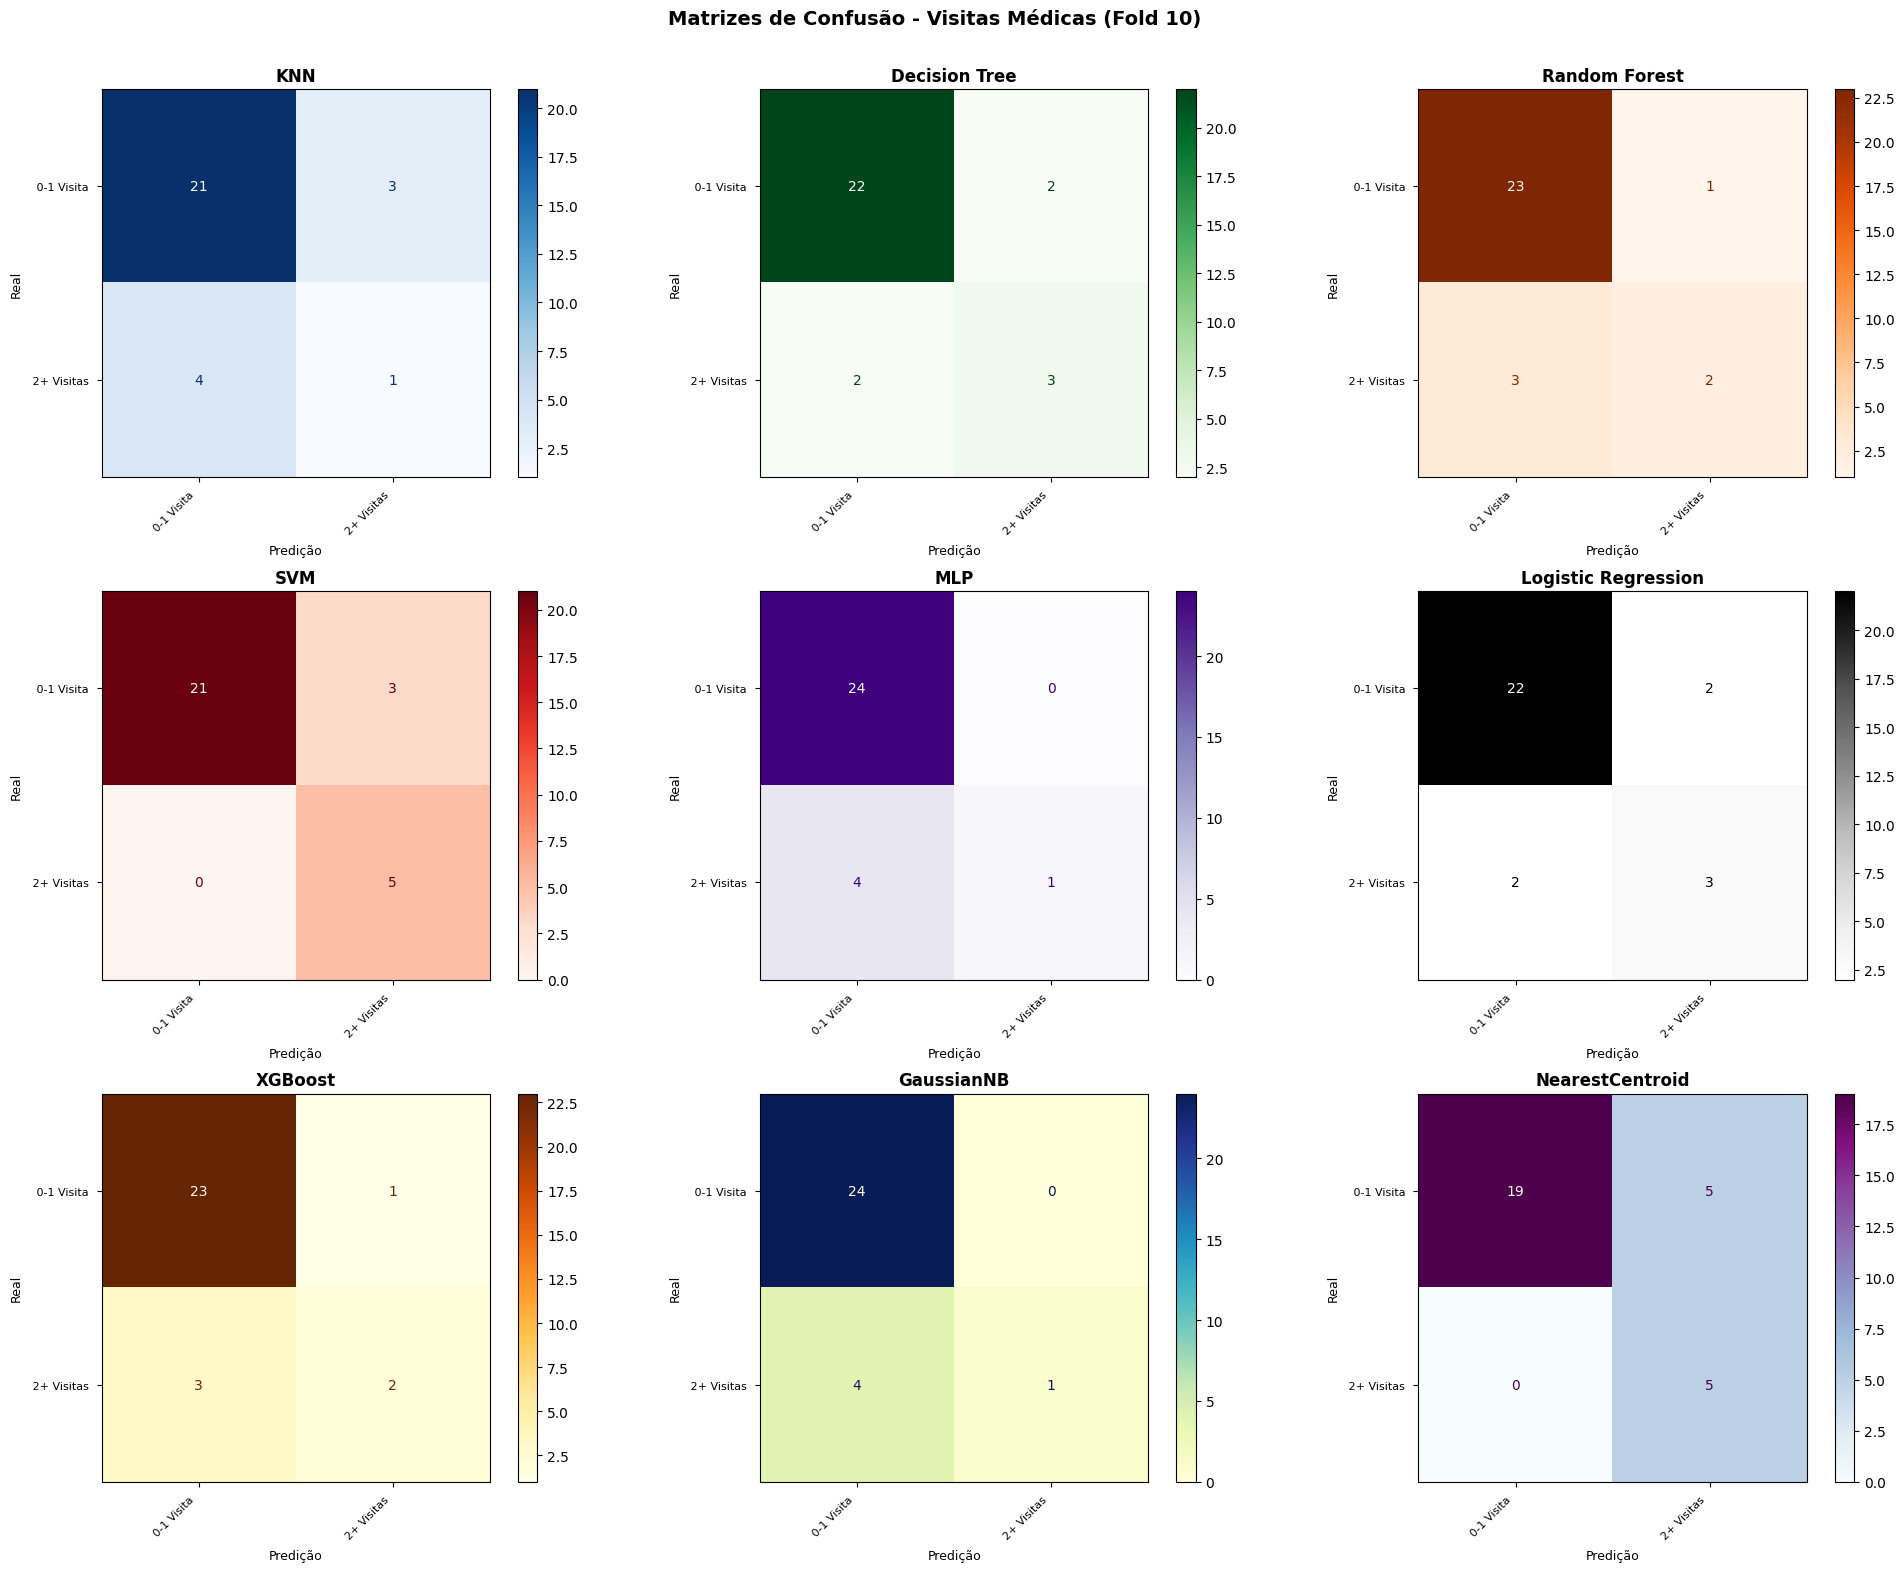

In [47]:
plt.figure(figsize=(20, 16))  # altura maior para 3 linhas
models = ['KNN', 'Decision Tree', 'Random Forest', 'SVM', 'MLP', 'Logistic Regression', 'XGBoost', 'GaussianNB', 'NearestCentroid']
confusion_matrices = [cm_knn, cm_dt, cm_rf, cm_svm, cm_mlp, cm_lr, cm_xgb, cm_nb, cm_nc]
colors = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'Greys', 'YlOrBr', 'YlGnBu', 'BuPu']

class_labels = [' 0-1 Visita ', ' 2+ Visitas ']

for j, (model, cm, color) in enumerate(zip(models, confusion_matrices, colors)):
    plt.subplot(3, 3, j+1)  # ← (3, 3) em vez de (2, 4)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=color, ax=plt.gca(), values_format='d')

    plt.title(f'{model}', fontsize=12, fontweight='bold')
    plt.xlabel('Predição', fontsize=9)
    plt.ylabel('Real', fontsize=9)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)

plt.suptitle(f'Matrizes de Confusão - Visitas Médicas (Fold {i+1})',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [48]:

all_metrics_results = {
    'Acurácia': [
        ('KNeighborsClassifier', acc_test_scores_KNN),
        ('DecisionTreeClassifier', acc_test_scores_DT),
        ('RandomForestClassifier', acc_test_scores_RF),
        ('SVM', acc_test_scores_SVM),
        ('MLPClassifier', acc_test_scores_MLP),
        ('LogisticRegression', acc_test_scores_LR),
        ('XGBClassifier', acc_test_scores_XGB),
        ('GaussianNB', acc_test_scores_NB),
        ('NearestCentroid', acc_test_scores_NC)
         
    ],
    'Precisão': [
        ('KNeighborsClassifier', precision_test_scores_KNN),
        ('DecisionTreeClassifier', precision_test_scores_DT),
        ('RandomForestClassifier', precision_test_scores_RF),
        ('SVM', precision_test_scores_SVM),
        ('MLPClassifier', precision_test_scores_MLP),
        ('LogisticRegression', precision_test_scores_LR),
        ('XGBClassifier', precision_test_scores_XGB),
        ('GaussianNB', precision_test_scores_NB),
        ('NearestCentroid', precision_test_scores_NC)

    ],
    'Recall': [
        ('KNeighborsClassifier', recall_test_scores_KNN),
        ('DecisionTreeClassifier', recall_test_scores_DT),
        ('RandomForestClassifier', recall_test_scores_RF),
        ('SVM', recall_test_scores_SVM),
        ('MLPClassifier', recall_test_scores_MLP),
        ('LogisticRegression', recall_test_scores_LR),
        ('XGBClassifier', recall_test_scores_XGB),
        ('GaussianNB', recall_test_scores_NB),
        ('NearestCentroid', recall_test_scores_NC)

    ],
    'F1-Score': [
        ('KNeighborsClassifier', f1_test_scores_KNN),
        ('DecisionTreeClassifier', f1_test_scores_DT),
        ('RandomForestClassifier', f1_test_scores_RF),
        ('SVM', f1_test_scores_SVM),
        ('MLPClassifier', f1_test_scores_MLP),
        ('LogisticRegression', f1_test_scores_LR),
        ('XGBClassifier', f1_test_scores_XGB),
        ('GaussianNB', f1_test_scores_NB),
        ('NearestCentroid', f1_test_scores_NC)
    ]
}

alpha = 0.05

for metric_name, model_scores_list in all_metrics_results.items():

    for i in range(len(model_scores_list)):
        for j in range(i + 1, len(model_scores_list)):
            model1_name, scores1 = model_scores_list[i]
            model2_name, scores2 = model_scores_list[j]

            print(f"\nComparando {model1_name} x {model2_name}:")

            if len(scores1) != len(scores2):
                print(f"\t- ERRO: Tamanhos das listas de scores são diferentes.")
                continue
            if len(scores1) < 2:
                print("\t- ERRO: Não há scores suficientes para o teste.")
                continue

            try:
                stat, p_val = wilcoxon(scores1, scores2, zero_method='zsplit', correction=False)
            except ValueError as e:
                print(f"\t- AVISO: Teste de Wilcoxon não pôde ser calculado. ({e})")
                mean1 = np.mean(scores1)
                mean2 = np.mean(scores2)
                print(f"\t- Média {model1_name}: {mean1:.4f}")
                print(f"\t- Média {model2_name}: {mean2:.4f}")
                print("\t-> Sem conclusão estatística.")
                print("----------------------------------------")
                continue

            mean1 = np.mean(scores1)
            mean2 = np.mean(scores2)

            print(f"\t- Amostras (n): {len(scores1)}")
            print(f"\t- Média {model1_name}: {mean1:.4f}")
            print(f"\t- Média {model2_name}: {mean2:.4f}")
            print(f"\t- Estatística Z: {stat:.4f}")
            print(f"\t- Valor-p (p-value): {p_val:.4f}")

            if p_val < alpha:
                print(f"\t-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < {alpha}).")
                best_model = model1_name if mean1 > mean2 else model2_name
                print(f"\t-> Melhor modelo (pela média): {best_model}")
            else:
                print(f"\t-> Resultado: Sem diferença estatisticamente significativa (p >= {alpha}).")

            print("----------------------------------------")




Comparando KNeighborsClassifier x DecisionTreeClassifier:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.6559
	- Média DecisionTreeClassifier: 0.7529
	- Estatística Z: 6.0000
	- Valor-p (p-value): 0.0273
	-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05).
	-> Melhor modelo (pela média): DecisionTreeClassifier
----------------------------------------

Comparando KNeighborsClassifier x RandomForestClassifier:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.6559
	- Média RandomForestClassifier: 0.7429
	- Estatística Z: 6.0000
	- Valor-p (p-value): 0.0293
	-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05).
	-> Melhor modelo (pela média): RandomForestClassifier
----------------------------------------

Comparando KNeighborsClassifier x SVM:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.6559
	- Média SVM: 0.6763
	- Estatística Z: 20.0000
	- Valor-p (p-value): 0.4727
	-> Resultado: Sem diferença estatisticamente significativa (p >= 0.05).
---